In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

In [76]:
df = pd.read_csv(r"E:\Pyhton code\Data Sets\archive\mall customer data\Mall_Customers.csv")

print(df.head())
print(df.info())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


In [77]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [78]:
#Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [79]:
#DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)

In [80]:
#predicted clusters
preds = (labels == -1).astype(int)

print("Total anomalies:", np.sum(preds))

Total anomalies: 3


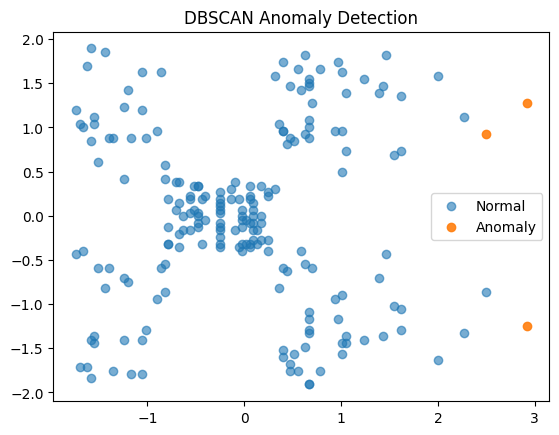

In [81]:
#Plotting the clusters
plt.figure()

plt.scatter(X_scaled[preds == 0, 0], X_scaled[preds == 0, 1], label="Normal", alpha=0.6)
plt.scatter(X_scaled[preds == 1, 0], X_scaled[preds == 1, 1], label="Anomaly", alpha=0.9)

plt.title("DBSCAN Anomaly Detection")
plt.legend()
plt.show()

In [82]:
#model evaluation
from sklearn.metrics import silhouette_score
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.35044619989666004


In [83]:
# Basic features
df["spend_income_ratio"] = df["Spending Score (1-100)"] / (df["Annual Income (k$)"] + 1e-6)

df["income_age_ratio"] = df["Annual Income (k$)"] / (df["Age"] + 1e-6)

df["income_dev"] = df["Annual Income (k$)"] - df["Annual Income (k$)"].mean()
df["spend_dev"] = df["Spending Score (1-100)"] - df["Spending Score (1-100)"].mean()

df["behavior_score"] = df["Annual Income (k$)"] * df["Spending Score (1-100)"]

In [84]:
# Ensure the required columns exist
if "income_dev" not in df.columns:
    df["income_dev"] = df["Annual Income (k$)"] - df["Annual Income (k$)"].mean()
if "spend_dev" not in df.columns:
    df["spend_dev"] = df["Spending Score (1-100)"] - df["Spending Score (1-100)"].mean()
if "behavior_score" not in df.columns:
    df["behavior_score"] = df["Annual Income (k$)"] * df["Spending Score (1-100)"]

X_new = df[["spend_income_ratio", "income_age_ratio", "income_dev", "spend_dev", "behavior_score"]].copy()

In [85]:
scaler = StandardScaler()
X_scaled_new = scaler.fit_transform(X_new)

In [86]:
pca = PCA(n_components=2)
X_pca= pca.fit_transform(X_scaled_new)

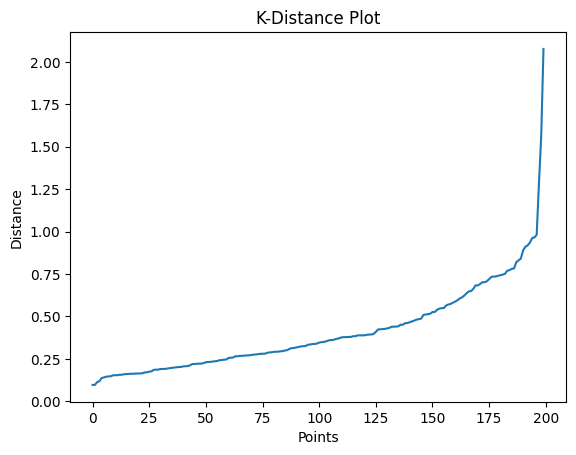

In [87]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_pca)

distances, indices = neighbors_fit.kneighbors(X_pca)

distances = np.sort(distances[:, 4])

plt.plot(distances)
plt.title("K-Distance Plot")
plt.xlabel("Points")
plt.ylabel("Distance")
plt.show()

In [88]:
for eps in [0.5, 0.7, 0.9, 1.1]:
    model = DBSCAN(eps=eps, min_samples=5)
    labels = model.fit_predict(X_pca)
    
    preds = (labels == -1).astype(int)
    
    print(f"EPS={eps} → Anomalies: {np.sum(preds)}")

EPS=0.5 → Anomalies: 39
EPS=0.7 → Anomalies: 9
EPS=0.9 → Anomalies: 3
EPS=1.1 → Anomalies: 1


In [89]:
preds = (labels == -1).astype(int)

print("Total anomalies:", np.sum(preds))

Total anomalies: 1


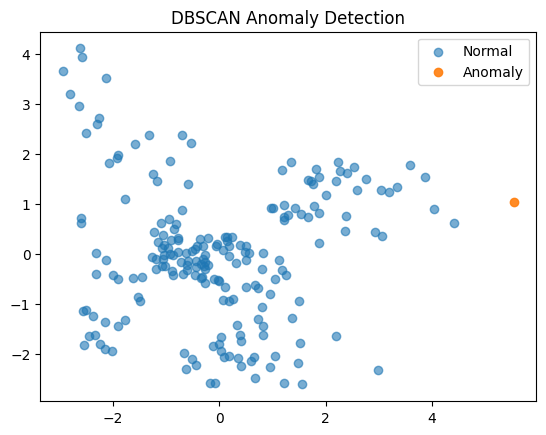

In [90]:
plt.figure()

plt.scatter(X_pca[preds == 0, 0], X_pca[preds == 0, 1], label="Normal", alpha=0.6)
plt.scatter(X_pca[preds == 1, 0], X_pca[preds == 1, 1], label="Anomaly", alpha=0.9)

plt.title("DBSCAN Anomaly Detection")
plt.legend()
plt.show()

In [91]:
df["Anomaly"] = preds

anomalies = df[df["Anomaly"] == 1]

print(anomalies.head())

     CustomerID Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
199         200  Male   30                 137                      83   

     spend_income_ratio  income_age_ratio  income_dev  spend_dev  \
199            0.605839          4.566667       76.44       32.8   

     behavior_score  Anomaly  
199           11371        1  


In [92]:
#model evaluation
from sklearn.metrics import silhouette_score
new_score = silhouette_score(X_pca, clusters)
print("New Silhouette Score:", new_score)
print("Old Silhouette Score:", score)

New Silhouette Score: 0.37807058428643786
Old Silhouette Score: 0.35044619989666004
